# UAV Crack Detection using U-Net

Model path: `../checkpoints/public_to_actual/CFD_actual_v1/Seg_UNET_v1_best.pth`

This notebook implements a U-Net model for crack detection in UAV imagery. It includes data loading, augmentation, model definition, training, and evaluation.

In [1]:
# Mount Google Drive to access datasets and save models
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- Configuration Parameters ---
# Update these paths to match your Google Drive structure
# DATA_DIR = Path('/content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/public_images/CrackDataset/CFD')
DATA_DIR = Path('/content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked')

# Training data paths
IMG_DIR = DATA_DIR / 'train/images'
MASK_DIR = DATA_DIR / 'train/masks'

# Validation data paths
VAL_IMG_DIR = DATA_DIR / 'valid/images'
VAL_MASK_DIR = DATA_DIR / 'valid/masks'

# Test data paths
TEST_IMG_DIR = DATA_DIR / 'test/images'
TEST_MASK_DIR = DATA_DIR / 'test/masks'

# Training Parameters
IMG_SIZE = (512, 512) # Patch size for training and validation image resize for full images
BATCH_SIZE = 8 # Further reduced to 2 to try and resolve persistent OOM with 512x512 images
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE = IMG_SIZE[0] # Square patches for simplicity (e.g., 512)
OVERLAP_RATIO = 0.2 # 20% overlap between patches for smooth stitching
CONFIDENCE_THRESHOLD = 0.5 # Adjusted threshold for better crack segmentation
OUTPUT_DIR = "/content/drive/MyDrive/UAV_Segmentation_Results/" # Directory to save results

print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Data Augmentation Pipelines
These functions define the data augmentation strategies for training and validation. Albumentations is used for efficient image transformations.

In [3]:
def get_train_augmentation():
    """Augmentations to promote morphological generalization."""
    return A.Compose([
        # A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1]), # Removed: Patch extraction handles size
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2), # Helps with shape variations
        A.GridDistortion(num_steps=5, distort_limit=0.05, p=0.2),     # Another deformation
        A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.2),
        A.RandomBrightnessContrast(p=0.3),
        A.CLAHE(p=0.1), # Apply CLAHE occasionally to boost contrast for thin features
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet stats
        ToTensorV2(),
    ])

def get_val_augmentation():
    """Simple augmentation for validation."""
    return A.Compose([
        A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1]),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_inference_transform():
    """Standard normalization used during training for model input."""
    return A.Compose([
        A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1]), # Added resizing for inference
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet stats
        ToTensorV2(),
    ])

## 3. Custom Dataset Class
The `CrackDataset` class handles loading images and their corresponding masks from the specified directories, applying augmentations, and preparing them for the PyTorch DataLoader.

In [4]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm


# Dataset Class
class CrackDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, patch_based_training=False, img_size=(512, 512)):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.patch_based_training = patch_based_training
        self.img_size = img_size # Expected output size, for patch extraction
        self.image_files = sorted(
            list(self.img_dir.glob("*.jpg")) +
            list(self.img_dir.glob("*.jpeg")) +
            list(self.img_dir.glob("*.png"))
        )
        assert len(self.image_files) > 0, f"No images found in {img_dir}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]

        # Construct mask_path by changing the image file's extension to match the original image
        mask_path = self.mask_dir / (img_path.stem + img_path.suffix) # Changed this line to use image's suffix

        try:
            # Load image and mask
            image = cv2.imread(str(img_path))
            if image is None:
                print(f"Warning: Image file not found or unreadable: {img_path}. Skipping this sample.")
                return None, None # Skip this sample
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

            # Check if mask was loaded successfully
            if mask is None:
                # This means the file exists but cv2.imread returned None, indicating a problem with the file content
                print(f"Warning: Mask file exists but is unreadable (returned None): {mask_path}. Skipping this sample.")
                return None, None # Skip this sample

            # Assuming white pixels in mask represent cracks (value 255)
            mask = (mask > 127).astype(np.float32) # Convert to 0.0 (background) and 1.0 (crack)

            if self.patch_based_training:
                # Randomly extract a patch of IMG_SIZE
                h, w = image.shape[:2]
                # Ensure patch_size is not larger than image dimensions
                patch_h, patch_w = self.img_size

                if h < patch_h or w < patch_w:
                    # If image is smaller than patch size, resize it up
                    # This is a fallback and might not be ideal, but ensures compatibility
                    image = cv2.resize(image, (max(w, patch_w), max(h, patch_h)), interpolation=cv2.INTER_LINEAR)
                    mask = cv2.resize(mask, (max(w, patch_h), max(h, patch_w)), interpolation=cv2.INTER_NEAREST)
                    h, w = image.shape[:2]

                y = np.random.randint(0, h - patch_h + 1)
                x = np.random.randint(0, w - patch_w + 1)

                image = image[y:y+patch_h, x:x+patch_w]
                mask = mask[y:y+patch_h, x:x+patch_w]

            # Apply augmentations (which should not include A.Resize if patch_based_training is True)
            if self.transform:
                transformed = self.transform(image=image, mask=mask)
                image = transformed["image"]
                mask = transformed["mask"]

            # Ensure mask has channel dimension [H, W] -> [1, H, W]
            mask = torch.unsqueeze(mask, dim=0) # Crucial for BCEWithLogitsLoss
            return image, mask

        except FileNotFoundError:
            print(f"Warning: Mask file not found: {mask_path}. Skipping this sample.")
            return None, None # Skip this sample
        except Exception as e:
            print(f"Warning: An error occurred processing {img_path} or {mask_path}: {e}. Skipping this sample.")
            return None, None

In [5]:
# Re-execute data loader preparation
print(f"Loading dataset from {IMG_DIR} and {MASK_DIR}")

# Custom collate_fn to filter out None values from the dataset
def custom_collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch)) # Filter out samples where image is None
    if not batch:
        return None, None # Return None if the batch is empty after filtering
    return torch.utils.data.dataloader.default_collate(batch)

# Load full dataset using training augmentations initially
# For training, use patch-based loading, so A.Resize is removed from get_train_augmentation
full_dataset = CrackDataset(IMG_DIR, MASK_DIR, transform=get_train_augmentation(), patch_based_training=True, img_size=IMG_SIZE)

# Split into train and validation sets (e.g., 80/20 split)
train_indices, val_indices = train_test_split(
    list(range(len(full_dataset))), test_size=0.2, random_state=42
)

# Create Subset objects for train and validation
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)

# For the validation dataset, we should ideally use validation-specific augmentations (resizing + normalization)
# So, re-initialize val_dataset with val_augmentation. It will resize the entire image.
val_full_dataset = CrackDataset(IMG_DIR, MASK_DIR, transform=get_val_augmentation(), patch_based_training=False, img_size=IMG_SIZE)
val_dataset = torch.utils.data.Subset(val_full_dataset, val_indices)

# Create data loaders with the custom collate_fn
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Loading dataset from /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/train/images and /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/train/masks
Training samples: 20, Validation samples: 5


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_5301/1723122335.py:9: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2), # Helps with shape variations
/tmp/ipykernel_5301/1723122335.py:11: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.2),


## 4. U-Net Model Architecture
This section defines the U-Net architecture, which is a popular convolutional neural network for image segmentation tasks. It consists of `DoubleConv` (two convolutional layers), `Down` (downsampling path), `Up` (upsampling path with skip connections), and `OutConv` (output layer).

In [6]:
# U-Net Model Definition
class DoubleConv(nn.Module):
    """ (convolution => [BN] => ReLU) * 2 """
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """ Downscaling with maxpool then double conv """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """ Upscaling then double conv """
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Input tensor might not be perfectly divisible by 2, so crop x2 to match x1's size
        # This handles potential size mismatches due to padding in earlier layers or odd input dimensions
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        # Pad x1 if necessary to match x2's size (or crop x2 if it's larger)
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4) # F.pad needs to be imported or handled in Up()
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

## 5. Loss Function


The `focal_tversky_loss function`. This loss function is particularly useful for imbalanced datasets and focuses on hard-to-segment examples.

In [7]:
# Loss Function (Focal Tversky Loss)
def focal_tversky_loss(inputs, targets, alpha=0.7, beta=0.3, gamma=1.5):
    """Calculates Focal Tversky Loss."""
    # Sigmoid to get probabilities
    inputs = torch.sigmoid(inputs)

    # Flatten tensors
    inputs = inputs.view(-1)
    targets = targets.view(-1)

    # Calculate True Positives, False Positives, and False Negatives
    TP = (inputs * targets).sum()
    FP = ((1 - targets) * inputs).sum()
    FN = (targets * (1 - inputs)).sum()

    # Tversky Index
    Tversky = (TP + 1e-7) / (TP + alpha * FP + beta * FN + 1e-7)

    # Focal Tversky Loss
    loss = (1 - Tversky) ** gamma

    return loss

## 6. Prepare DataLoaders
This section initializes the `CrackDataset`, splits it into training and validation sets, and creates `DataLoader` instances for batching and shuffling the data during training.

In [8]:
# Prepare Dataset and DataLoaders
print(f"Loading dataset from {IMG_DIR} and {MASK_DIR}")

# Custom collate_fn to filter out None values from the dataset
def custom_collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch)) # Filter out samples where image is None
    if not batch:
        return None, None # Return None if the batch is empty after filtering
    return torch.utils.data.dataloader.default_collate(batch)

# Load full dataset using training augmentations initially
# For training, use patch-based loading, so A.Resize is removed from get_train_augmentation
full_dataset = CrackDataset(IMG_DIR, MASK_DIR, transform=get_train_augmentation(), patch_based_training=True, img_size=IMG_SIZE)

# Split into train and validation sets (e.g., 80/20 split)
train_indices, val_indices = train_test_split(
    list(range(len(full_dataset))), test_size=0.2, random_state=42
)

# Create Subset objects for train and validation
train_dataset = torch.utils.data.Subset(full_dataset, train_indices)

# For the validation dataset, we should ideally use validation-specific augmentations (resizing + normalization)
# So, re-initialize val_dataset with val_augmentation. It will resize the entire image.
val_full_dataset = CrackDataset(IMG_DIR, MASK_DIR, transform=get_val_augmentation(), patch_based_training=False, img_size=IMG_SIZE)
val_dataset = torch.utils.data.Subset(val_full_dataset, val_indices)

# Create data loaders with the custom collate_fn
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=custom_collate_fn)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Loading dataset from /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/train/images and /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/train/masks
Training samples: 20, Validation samples: 5


/tmp/ipykernel_5301/1723122335.py:9: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2), # Helps with shape variations
/tmp/ipykernel_5301/1723122335.py:11: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=0.2),


## 7. Training Loop (Careful)
This is the main training logic. It initializes the U-Net model, optimizer, and learning rate scheduler. The model is trained for a specified number of epochs, with validation performed after each epoch. The best model based on validation loss is saved to Google Drive.

In [9]:
import os

# Re-execute the training loop

# Initialize Model, Optimizer, and Scheduler (re-initialize to ensure fresh state if previous run crashed)
model = UNet(n_channels=3, n_classes=1).to(DEVICE) # 3 channels for RGB input, 1 class for binary segmentation

# Load pre-trained weights for fine-tuning
pretrained_model_path = '/content/Seg_UNET_v1_best.pth'
if os.path.exists(pretrained_model_path):
    model.load_state_dict(torch.load(pretrained_model_path, map_location=DEVICE))
    print(f"Successfully loaded pre-trained model from {pretrained_model_path} for fine-tuning.")
else:
    print(f"Warning: Pre-trained model not found at {pretrained_model_path}. Starting training from scratch.")

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Training Loop
best_val_loss = float('inf')
train_losses = []
val_losses = []

# Early Stopping Parameters
patience = 10 # Number of epochs to wait if no improvement in validation loss
min_delta = 0.001 # Minimum change to be considered an improvement
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 10)

    # --- Training Phase ---
    model.train() # Set model to training mode
    running_train_loss = 0.0
    num_train_batches = 0
    for images, masks in tqdm(train_loader, desc="Training"):
        if images is None or masks is None: # Skip batches that are entirely None due to custom_collate_fn
            continue
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = focal_tversky_loss(outputs, masks) # Changed from hybrid_loss to focal_tversky_loss
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        num_train_batches += 1

    if num_train_batches > 0: # Ensure at least one valid batch was processed
        avg_train_loss = running_train_loss / num_train_batches
        train_losses.append(avg_train_loss)
        print(f"Train Loss: {avg_train_loss:.4f}")
    else:
        print("No valid training batches processed in this epoch.")
        train_losses.append(train_losses[-1] if train_losses else 0.0) # Append last known loss or 0


    # --- Validation Phase ---
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    val_batch_count = 0
    with torch.no_grad(): # Disable gradient computation for validation
        for images, masks in tqdm(val_loader, desc="Validating"):
            if images is None or masks is None: # Skip batches that are entirely None
                continue
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            loss = focal_tversky_loss(outputs, masks) # Changed from hybrid_loss to focal_tversky_loss
            running_val_loss += loss.item()
            val_batch_count += 1

    if val_batch_count > 0:
        avg_val_loss = running_val_loss / val_batch_count
        val_losses.append(avg_val_loss)
        print(f"Validation Loss: {avg_val_loss:.4f}")

        # Scheduler step based on validation loss
        scheduler.step(avg_val_loss)

        # Early stopping logic and Save the best model
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            patience_counter = 0
            model_save_path = f'/content/best_uav_crack_unet.pth'
            torch.save(model.state_dict(), model_save_path)
            print(f"New best model saved to {model_save_path}")
        else:
            patience_counter += 1
            print(f"Validation loss did not improve. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping triggered after {patience} epochs without improvement.")
                break # Exit the training loop
    else:
        print("No valid validation batches processed in this epoch. Skipping scheduler step and early stopping for this epoch.")
        val_losses.append(val_losses[-1] if val_losses else 0.0)

print("\nTraining Complete.")
print(f"Best validation loss: {best_val_loss:.4f}")

Successfully loaded pre-trained model from /content/Seg_UNET_v1_best.pth for fine-tuning.

Epoch 1/50
----------


Training: 100%|██████████| 3/3 [00:08<00:00,  3.00s/it]


Train Loss: 0.7871


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


Validation Loss: 0.9696
New best model saved to /content/best_uav_crack_unet.pth

Epoch 2/50
----------


...

Validation Loss: 0.9585
Validation loss did not improve. Patience: 9/10

Epoch 19/50
----------


Training: 100%|██████████| 3/3 [00:08<00:00,  2.86s/it]


Train Loss: 0.7259


Validating: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]

Validation Loss: 0.9624
Validation loss did not improve. Patience: 10/10
Early stopping triggered after 10 epochs without improvement.

Training Complete.
Best validation loss: 0.9339


Let's list a few files from your image and mask directories to help you debug:

## 8. Visualize Training History (Only after Training)
This section plots the training and validation loss curves over epochs, providing insights into the model's learning progress and potential overfitting.

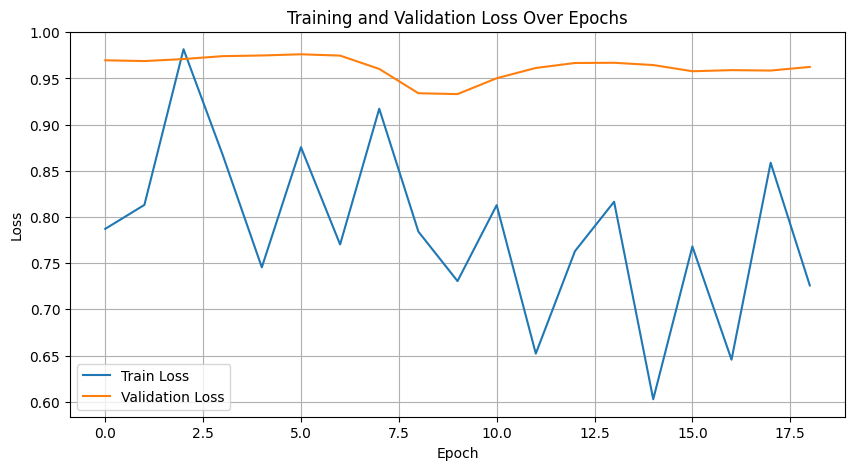

Model training complete. Best model state dictionary saved to Google Drive.


In [15]:
3# Plot Training and Validation Losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Model training complete. Best model state dictionary saved to Google Drive.")

# 9. Segmentation Metrics

We will use metrics such as: `IoU`, `Dice/F1`, `Precision`, `Recall`, `Pixel Accuracy`

In [16]:
import numpy as np
import torch

def calculate_metrics(y_true, y_pred, epsilon=1e-7):
    """
    Calculates common segmentation metrics.
    Args:
        y_true (np.array or torch.Tensor): Ground truth binary mask (0 or 1).
        y_pred (np.array or torch.Tensor): Predicted binary mask (0 or 1).
        epsilon (float): Small value to prevent division by zero.

    Returns:
        dict: A dictionary containing calculated metrics.
    """
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().numpy()

    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    # Flatten for easier calculation
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    TP = np.sum(y_true_flat & y_pred_flat)  # True Positives
    FP = np.sum(~y_true_flat & y_pred_flat) # False Positives
    FN = np.sum(y_true_flat & ~y_pred_flat) # False Negatives
    TN = np.sum(~y_true_flat & ~y_pred_flat) # True Negatives

    # Pixel Accuracy
    pixel_accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)

    # IoU (Intersection over Union) / Jaccard Index
    iou = TP / (TP + FP + FN + epsilon)

    # Dice Coefficient / F1-score
    dice = (2 * TP) / (2 * TP + FP + FN + epsilon)

    # Precision
    precision = TP / (TP + FP + epsilon)

    # Recall (Sensitivity)
    recall = TP / (TP + FN + epsilon)

    return {
        "pixel_accuracy": pixel_accuracy,
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }

print("Segmentation metrics functions defined.")

Segmentation metrics functions defined.


# 10. Evaluate Segmentation Metrics

This section calculates various segmentation metrics (IoU, Dice, Precision, Recall, Pixel Accuracy) for each image processed during inference, comparing the predicted binary mask with the ground truth mask. Finally, it computes and displays the average metrics across all evaluated images.

In [17]:
import os
from pathlib import Path
import numpy as np
import torch
import cv2
from PIL import Image # Added for read_image_as_rgb

# Helper function for reading images
def read_image_as_rgb(image_path):
    """Reads an image as RGB using PIL and converts to numpy array."""
    img = Image.open(image_path).convert('RGB')
    return np.array(img)

def apply_clahe(image):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to enhance local contrast."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # Tune these parameters for optimal contrast
    cl = clahe.apply(l_channel)
    limg = cv2.merge((cl,a_channel,b_channel))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_img

def tta_forward(model, image_tensor):
    """Apply Test-Time Augmentation by averaging predictions from different transformations (flips, rotations)."""
    # Original prediction
    with torch.no_grad():
        orig_pred = torch.sigmoid(model(image_tensor.unsqueeze(0))) # Add batch dimension

    # Horizontal Flip
    h_flip_pred = torch.flip(torch.sigmoid(model(torch.flip(image_tensor.unsqueeze(0), dims=[3]))), dims=[3])

    # Vertical Flip
    v_flip_pred = torch.flip(torch.sigmoid(model(torch.flip(image_tensor.unsqueeze(0), dims=[2]))), dims=[2])

    # Rotate 90 degrees
    rot_90_pred = torch.rot90(torch.sigmoid(model(torch.rot90(image_tensor.unsqueeze(0), k=1, dims=[2, 3]))), k=-1, dims=[2, 3])

    # Average predictions
    averaged_pred = (orig_pred + h_flip_pred + v_flip_pred + rot_90_pred) / 4.0
    return averaged_pred.squeeze() # Changed from .squeeze(0) to .squeeze() to remove channel dim

def run_inference_on_large_image(image_path, model, patch_size, overlap_ratio, transform_func, tta_enabled=True):
    """
    Performs inference on a large image using a sliding window approach with optional TTA.
    It processes the image in patches, stitches predictions, and averages overlapping regions.
    """
    # Load and preprocess image
    original_image = read_image_as_rgb(image_path)
    original_h, original_w, _ = original_image.shape

    # Apply CLAHE before slicing to ensure consistent enhancement across patches
    preprocessed_image = apply_clahe(original_image)

    print(f"Processing image of size: {original_h}x{original_w}")

    # Calculate step size based on overlap ratio
    step_size = int(patch_size * (1 - overlap_ratio))

    # Initialize result array for the full image prediction (probabilities) and a count map
    # The count map tracks how many times each pixel has been predicted, for averaging overlaps.
    full_pred_map = np.zeros((original_h, original_w), dtype=np.float32)
    count_map = np.zeros((original_h, original_w), dtype=np.int32)

    # Iterate through the image with a sliding window, covering the main area
    for y in range(0, original_h - patch_size + 1, step_size):
        for x in range(0, original_w - patch_size + 1, step_size):
            # Extract patch
            patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]

            # Apply transformations (normalization, ToTensor)
            transformed = transform_func(image=patch_rgb)
            patch_tensor = transformed["image"].to(DEVICE)

            # Run inference on the patch, with or without TTA
            if tta_enabled:
                pred_prob = tta_forward(model, patch_tensor)
            else:
                with torch.no_grad():
                    pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0) # Remove batch and channel dims

            # Convert prediction back to numpy (CPU)
            pred_np = pred_prob.cpu().detach().numpy()

            # Add prediction to the full map and increment count for averaging
            full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
            count_map[y:y+patch_size, x:x+patch_size] += 1

    # Handle edge cases to ensure every part of the image is covered.
    # This ensures areas that might be missed by the main loop (if dimensions aren't perfect) are included.
    # The extra loops ensure full coverage, potentially re-processing some areas.
    if original_h % step_size != 0 or original_w % step_size != 0:
        # Process remaining rows at the bottom edge
        for x in range(0, original_w - patch_size + 1, step_size):
             y = original_h - patch_size
             patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
             transformed = transform_func(image=patch_rgb)
             patch_tensor = transformed["image"].to(DEVICE)
             if tta_enabled:
                 pred_prob = tta_forward(model, patch_tensor)
             else:
                 with torch.no_grad():
                     pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
             pred_np = pred_prob.cpu().detach().numpy()
             full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
             count_map[y:y+patch_size, x:x+patch_size] += 1

        # Process remaining columns at the right edge
        for y in range(0, original_h - patch_size + 1, step_size):
             x = original_w - patch_size
             patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
             transformed = transform_func(image=patch_rgb)
             patch_tensor = transformed["image"].to(DEVICE)
             if tta_enabled:
                 pred_prob = tta_forward(model, patch_tensor)
             else:
                 with torch.no_grad():
                     pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
             pred_np = pred_prob.cpu().detach().numpy()
             full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
             count_map[y:y+patch_size, x:x+patch_size] += 1

        # Process the bottom-right corner if necessary
        if original_h % step_size != 0 and original_w % step_size != 0:
            y = original_h - patch_size
            x = original_w - patch_size
            patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
            transformed = transform_func(image=patch_rgb)
            patch_tensor = transformed["image"].to(DEVICE)
            if tta_enabled:
                pred_prob = tta_forward(model, patch_tensor)
            else:
                with torch.no_grad():
                    pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
            pred_np = pred_prob.cpu().detach().numpy()
            full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
            count_map[y:y+patch_size, x:x+patch_size] += 1

    # Final step: average the predictions where patches overlapped to smooth transitions
    valid_count_mask = count_map > 0
    full_pred_map[valid_count_mask] /= count_map[valid_count_mask]

    # Threshold the averaged probability map to get the final binary mask
    final_binary_mask = (full_pred_map > CONFIDENCE_THRESHOLD).astype(np.uint8) * 255

    return original_image, full_pred_map, final_binary_mask

all_metrics = []

# Define input paths for images and masks for inference
BASE_TEST_DIR = Path('/content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test')
INPUT_IMAGES_PATH_INFERENCE = BASE_TEST_DIR / 'images'
INPUT_MASKS_PATH_INFERENCE = BASE_TEST_DIR / 'masks'

# Ensure the output directory exists (OUTPUT_DIR is assumed to be defined globally)
os.makedirs(OUTPUT_DIR, exist_ok=True)

image_files = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_files.extend(list(INPUT_IMAGES_PATH_INFERENCE.glob(ext)))

# Initialize the UNet model (architecture defined in earlier cells)
model = UNet(n_channels=3, n_classes=1).to(DEVICE)

# Load the trained weights from the best model saved during training
# Assuming the best model was saved to '/content/best_uav_crack_unet.pth'
model_path = '/content/best_uav_crack_unet.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print(f"Successfully loaded model from {model_path}")
else:
    print(f"Warning: Model not found at {model_path}. Please ensure training was completed and the model was saved correctly.")

# Set model to evaluation mode
model.eval()

if not image_files:
    print("No image files found for evaluation.")
else:
    print(f"Found {len(image_files)} images for metric calculation.")
    for i, current_image_path in enumerate(image_files):
        print(f"\nCalculating metrics for image {i+1}/{len(image_files)}: {current_image_path.name}")

        # Clear CUDA cache before processing each image to free up memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- Perform Inference to get binary_mask ---
        # We need original_img, prob_map, binary_mask and original_mask
        # Re-using the run_inference_on_large_image function from above
        original_img, prob_map, binary_mask = run_inference_on_large_image(
            str(current_image_path), model, PATCH_SIZE, OVERLAP_RATIO, get_inference_transform(), tta_enabled=False
        )

        # Load ground truth mask (similar to inference cell)
        mask_path = INPUT_MASKS_PATH_INFERENCE / current_image_path.name
        original_mask = None
        if mask_path.exists():
            original_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            # Ensure mask is binary (0 or 255)
            original_mask = (original_mask > 127).astype(np.uint8) * 255
        else:
            print(f"Warning: Ground truth mask not found for {current_image_path.name} at {mask_path}. Skipping metrics for this image.")
            continue

        # Resize original_mask to match binary_mask if necessary (should be the same size if inference is correct)
        if original_mask.shape != binary_mask.shape:
            print(f"Warning: Mismatch in mask shapes for {current_image_path.name}. Resizing ground truth mask.")
            original_mask = cv2.resize(original_mask, (binary_mask.shape[1], binary_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Calculate metrics
        metrics = calculate_metrics(original_mask, binary_mask)
        all_metrics.append(metrics)

        print(f"Metrics for {current_image_path.name}:")
        for k, v in metrics.items():
            if k not in ['TP', 'FP', 'FN', 'TN']:
                print(f"  {k.replace('_', ' ').title()}: {v:.4f}")

    # Calculate and print average metrics
    if all_metrics:
        avg_metrics = {
            k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0] if k not in ['TP', 'FP', 'FN', 'TN']
        }
        print("\n" + "="*30)
        print("Average Segmentation Metrics:")
        print("="*30)
        for k, v in avg_metrics.items():
            print(f"  {k.replace('_', ' ').title()}: {v:.4f}")
    else:
        print("No metrics could be calculated.")

Successfully loaded model from /content/best_uav_crack_unet.pth
Found 5 images for metric calculation.

Calculating metrics for image 1/5: photo_14_2026-05-26_10-16-13_jpg.rf.l9ZLegHgbYC3F7KZhC8I.jpg
Processing image of size: 2560x1920
Metrics for photo_14_2026-05-26_10-16-13_jpg.rf.l9ZLegHgbYC3F7KZhC8I.jpg:
  Pixel Accuracy: 0.9978
  Iou: 0.4176
  Dice: 0.5891
  Precision: 0.4494
  Recall: 0.8550

Calculating metrics for image 2/5: photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg
Processing image of size: 2560x1920
Metrics for photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg:
  Pixel Accuracy: 0.9885
  Iou: 0.2776
  Dice: 0.4346
  Precision: 0.4873
  Recall: 0.3921

Calculating metrics for image 3/5: photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg
Processing image of size: 2560x1920
Metrics for photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg:
  Pixel Accuracy: 0.9979
  Iou: 0.3780
  Dice: 0.5486
  Precision: 0.3785
  Recall: 0.9970

Ca

# 11. Inference on Large Images


This cell performs crack segmentation on large UAV images using the trained U-Net model.
It employs a sliding window approach with Test-Time Augmentation (TTA) and CLAHE preprocessing
to enhance prediction accuracy and handle image size limitations.


In [18]:
import os
import cv2
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

# Helper function for reading images
def read_image_as_rgb(image_path):
    """Reads an image as RGB using PIL and converts to numpy array."""
    img = Image.open(image_path).convert('RGB')
    return np.array(img)

# --- Preprocessing and Test-Time Augmentation (TTA) Functions ---
def get_inference_transform():
    """Standard normalization used during training for model input."""
    return A.Compose([
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet stats
        ToTensorV2(),
    ])

def apply_clahe(image):
    """Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to enhance local contrast."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)) # Tune these parameters for optimal contrast
    cl = clahe.apply(l_channel)
    limg = cv2.merge((cl,a_channel,b_channel))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return final_img

def tta_forward(model, image_tensor):
    """Apply Test-Time Augmentation by averaging predictions from different transformations (flips, rotations)."""
    # Original prediction
    with torch.no_grad():
        orig_pred = torch.sigmoid(model(image_tensor.unsqueeze(0))) # Add batch dimension

    # Horizontal Flip
    h_flip_pred = torch.flip(torch.sigmoid(model(torch.flip(image_tensor.unsqueeze(0), dims=[3]))), dims=[3])

    # Vertical Flip
    v_flip_pred = torch.flip(torch.sigmoid(model(torch.flip(image_tensor.unsqueeze(0), dims=[2]))), dims=[2])

    # Rotate 90 degrees
    rot_90_pred = torch.rot90(torch.sigmoid(model(torch.rot90(image_tensor.unsqueeze(0), k=1, dims=[2, 3]))), k=-1, dims=[2, 3])

    # Average predictions
    averaged_pred = (orig_pred + h_flip_pred + v_flip_pred + rot_90_pred) / 4.0
    return averaged_pred.squeeze() # Changed from .squeeze(0) to .squeeze() to remove channel dim


# --- Slicing and Stitching Logic ---
def run_inference_on_large_image(image_path, model, patch_size, overlap_ratio, transform_func, tta_enabled=True):
    """
    Performs inference on a large image using a sliding window approach with optional TTA.
    It processes the image in patches, stitches predictions, and averages overlapping regions.
    """
    # Load and preprocess image
    original_image = read_image_as_rgb(image_path)
    original_h, original_w, _ = original_image.shape

    # Apply CLAHE before slicing to ensure consistent enhancement across patches
    preprocessed_image = apply_clahe(original_image)

    print(f"Processing image of size: {original_h}x{original_w}")

    # Calculate step size based on overlap ratio
    step_size = int(patch_size * (1 - overlap_ratio))

    # Initialize result array for the full image prediction (probabilities) and a count map
    # The count map tracks how many times each pixel has been predicted, for averaging overlaps.
    full_pred_map = np.zeros((original_h, original_w), dtype=np.float32)
    count_map = np.zeros((original_h, original_w), dtype=np.int32)

    # Iterate through the image with a sliding window, covering the main area
    for y in range(0, original_h - patch_size + 1, step_size):
        for x in range(0, original_w - patch_size + 1, step_size):
            # Extract patch
            patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]

            # Apply transformations (normalization, ToTensor)
            transformed = transform_func(image=patch_rgb)
            patch_tensor = transformed["image"].to(DEVICE)

            # Run inference on the patch, with or without TTA
            if tta_enabled:
                pred_prob = tta_forward(model, patch_tensor)
            else:
                with torch.no_grad():
                    pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0) # Remove batch and channel dims

            # Convert prediction back to numpy (CPU)
            pred_np = pred_prob.cpu().detach().numpy()

            # Add prediction to the full map and increment count for averaging
            full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
            count_map[y:y+patch_size, x:x+patch_size] += 1

    # Handle edge cases to ensure every part of the image is covered.
    # This ensures areas that might be missed by the main loop (if dimensions aren't perfect) are included.
    # The extra loops ensure full coverage, potentially re-processing some areas.
    if original_h % step_size != 0 or original_w % step_size != 0:
        # Process remaining rows at the bottom edge
        for x in range(0, original_w - patch_size + 1, step_size):
             y = original_h - patch_size
             patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
             transformed = transform_func(image=patch_rgb)
             patch_tensor = transformed["image"].to(DEVICE)
             if tta_enabled:
                 pred_prob = tta_forward(model, patch_tensor)
             else:
                 with torch.no_grad():
                     pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
             pred_np = pred_prob.cpu().detach().numpy()
             full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
             count_map[y:y+patch_size, x:x+patch_size] += 1

        # Process remaining columns at the right edge
        for y in range(0, original_h - patch_size + 1, step_size):
             x = original_w - patch_size
             patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
             transformed = transform_func(image=patch_rgb)
             patch_tensor = transformed["image"].to(DEVICE)
             if tta_enabled:
                 pred_prob = tta_forward(model, patch_tensor)
             else:
                 with torch.no_grad():
                     pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
             pred_np = pred_prob.cpu().detach().numpy()
             full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
             count_map[y:y+patch_size, x:x+patch_size] += 1

        # Process the bottom-right corner if necessary
        if original_h % step_size != 0 and original_w % step_size != 0:
            y = original_h - patch_size
            x = original_w - patch_size
            patch_rgb = preprocessed_image[y:y+patch_size, x:x+patch_size, :]
            transformed = transform_func(image=patch_rgb)
            patch_tensor = transformed["image"].to(DEVICE)
            if tta_enabled:
                pred_prob = tta_forward(model, patch_tensor)
            else:
                with torch.no_grad():
                    pred_prob = torch.sigmoid(model(patch_tensor.unsqueeze(0))).squeeze(0).squeeze(0)
            pred_np = pred_prob.cpu().detach().numpy()
            full_pred_map[y:y+patch_size, x:x+patch_size] += pred_np
            count_map[y:y+patch_size, x:x+patch_size] += 1

    # Final step: average the predictions where patches overlapped to smooth transitions
    valid_count_mask = count_map > 0
    full_pred_map[valid_count_mask] /= count_map[valid_count_mask]

    # Threshold the averaged probability map to get the final binary mask
    final_binary_mask = (full_pred_map > CONFIDENCE_THRESHOLD).astype(np.uint8) * 255

    return original_image, full_pred_map, final_binary_mask

Found 5 images in /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images. Starting inference...

Processing image 1/5: photo_14_2026-05-26_10-16-13_jpg.rf.l9ZLegHgbYC3F7KZhC8I.jpg
Starting inference on /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images/photo_14_2026-05-26_10-16-13_jpg.rf.l9ZLegHgbYC3F7KZhC8I.jpg
Processing image of size: 2560x1920
Inference complete.


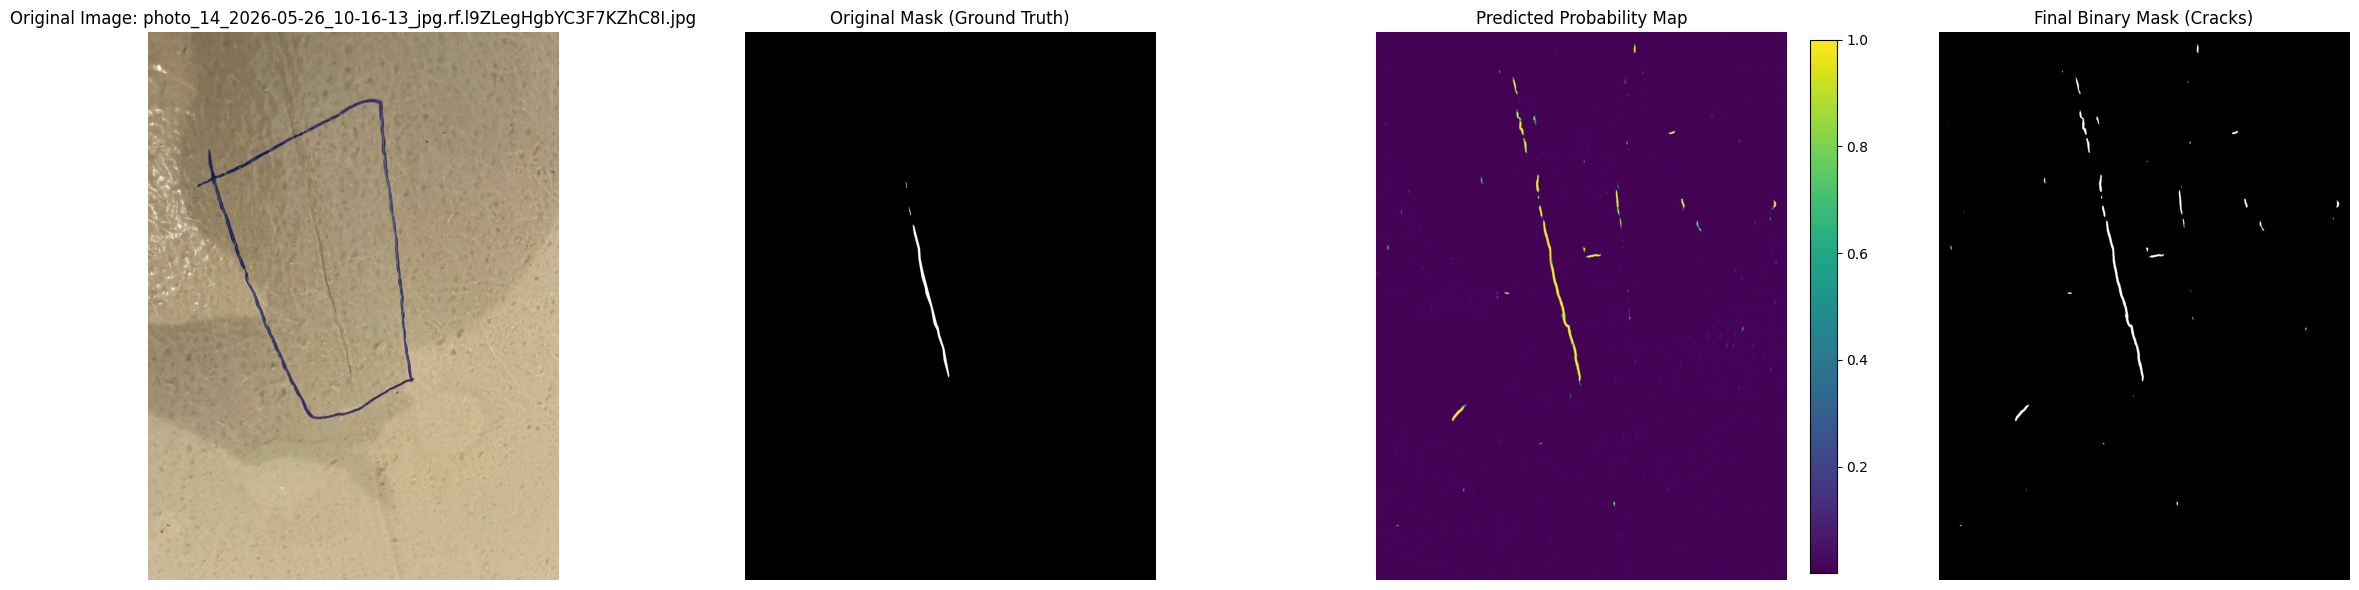

Results for photo_14_2026-05-26_10-16-13_jpg.rf.l9ZLegHgbYC3F7KZhC8I.jpg saved to /content/drive/MyDrive/UAV_Segmentation_Results/

Processing image 2/5: photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg
Starting inference on /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images/photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg
Processing image of size: 2560x1920
Inference complete.


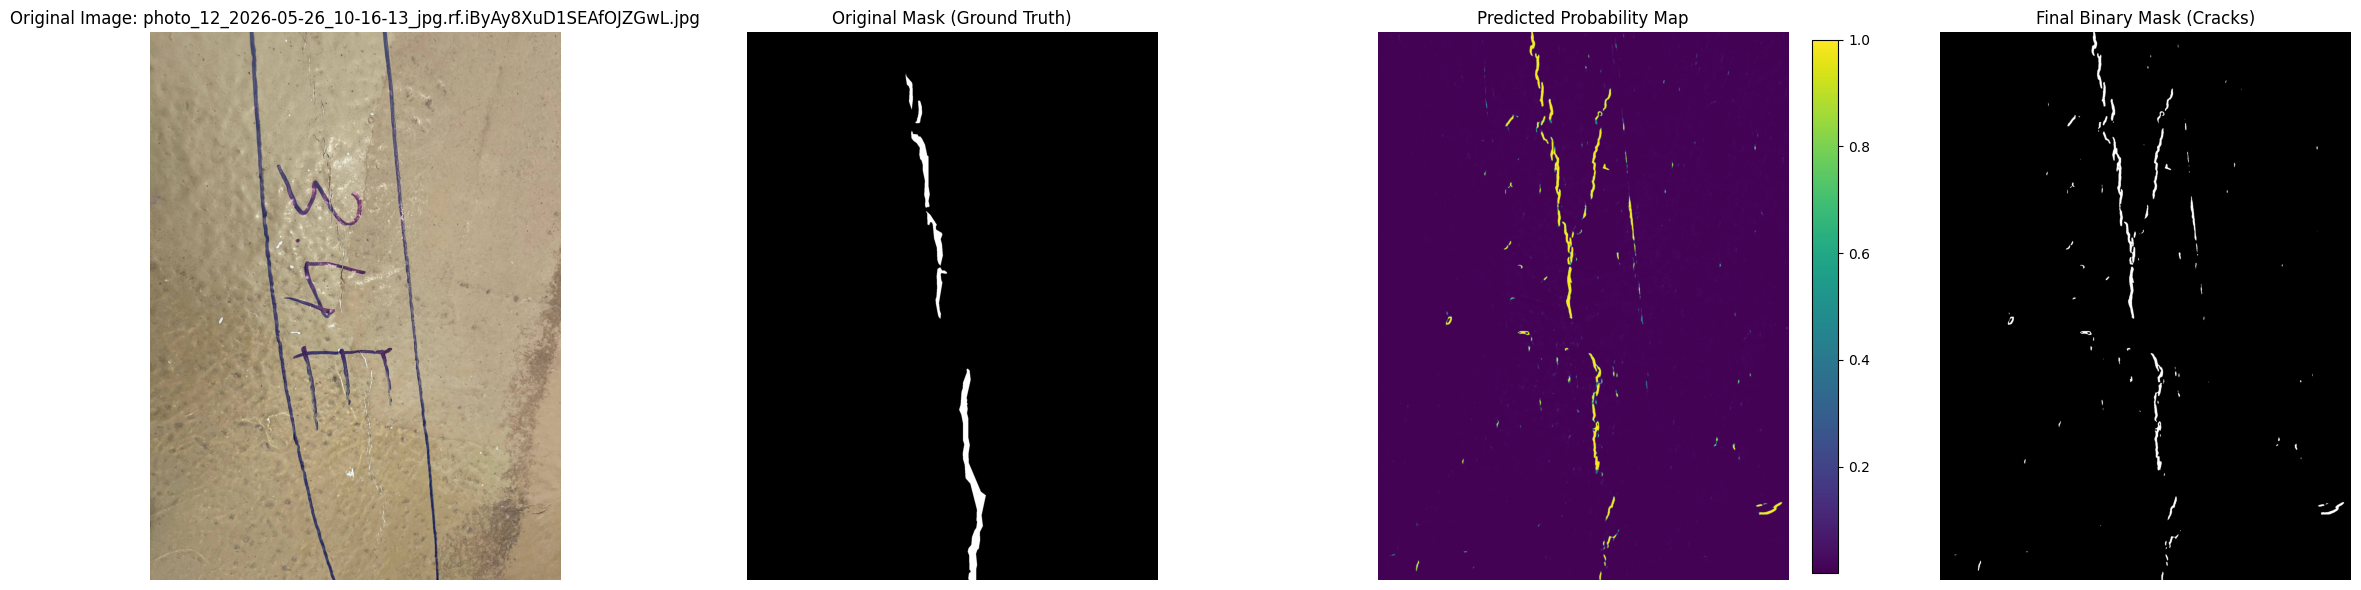

Results for photo_12_2026-05-26_10-16-13_jpg.rf.iByAy8XuD1SEAfOJZGwL.jpg saved to /content/drive/MyDrive/UAV_Segmentation_Results/

Processing image 3/5: photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg
Starting inference on /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images/photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg
Processing image of size: 2560x1920
Inference complete.


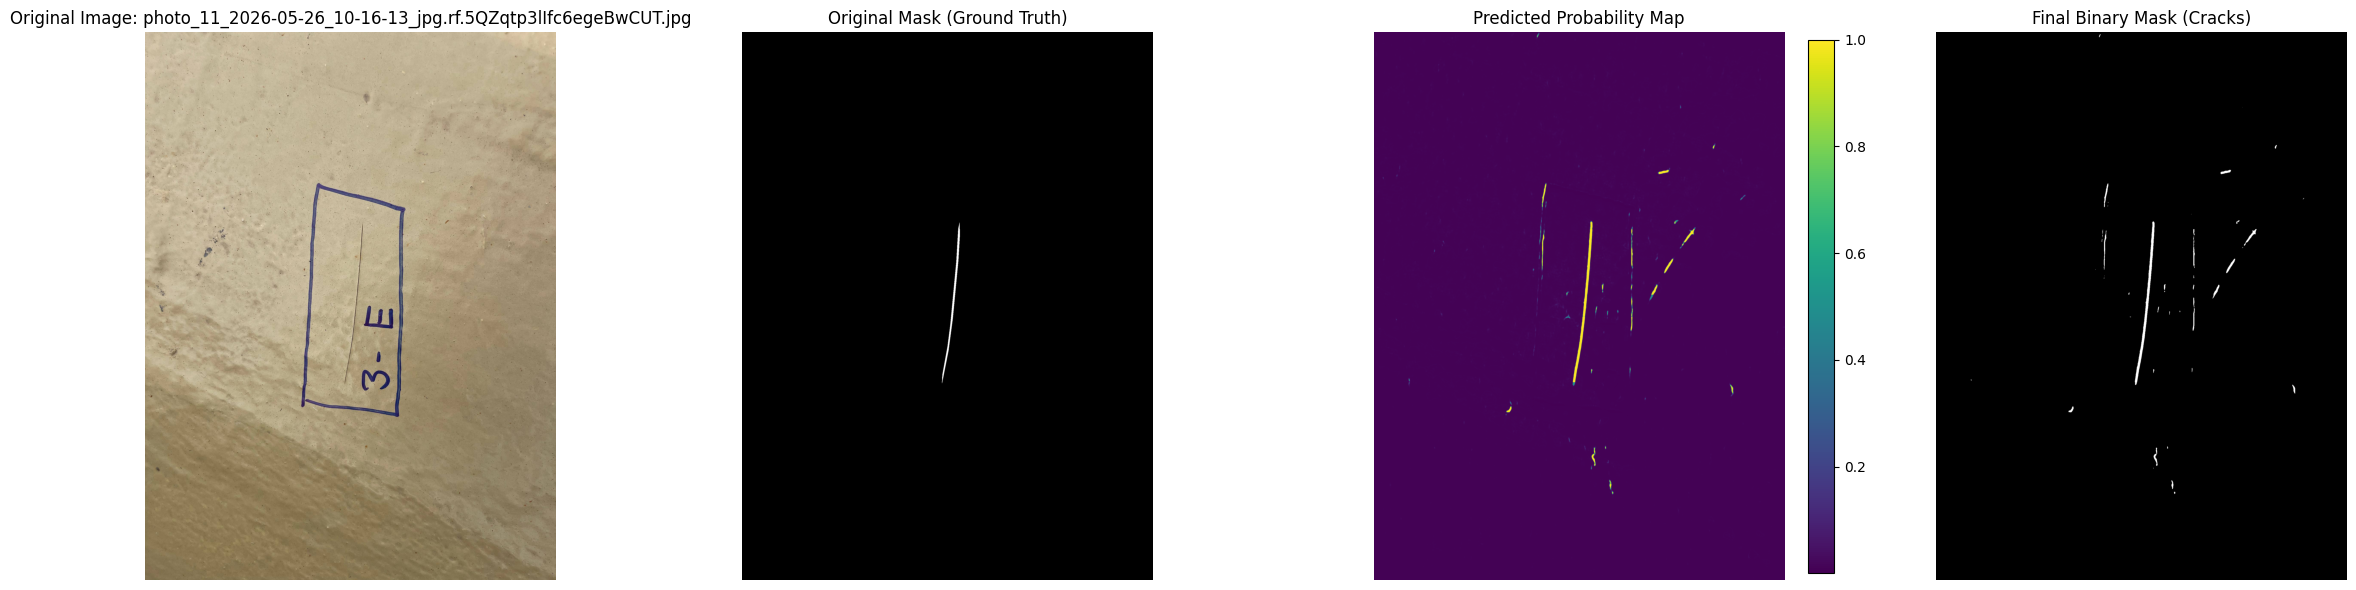

Results for photo_11_2026-05-26_10-16-13_jpg.rf.5QZqtp3lIfc6egeBwCUT.jpg saved to /content/drive/MyDrive/UAV_Segmentation_Results/

Processing image 4/5: photo_10_2026-05-26_10-16-13_jpg.rf.sip1yGpVYT0FCVvRq4K2.jpg
Starting inference on /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images/photo_10_2026-05-26_10-16-13_jpg.rf.sip1yGpVYT0FCVvRq4K2.jpg
Processing image of size: 1920x2560
Inference complete.


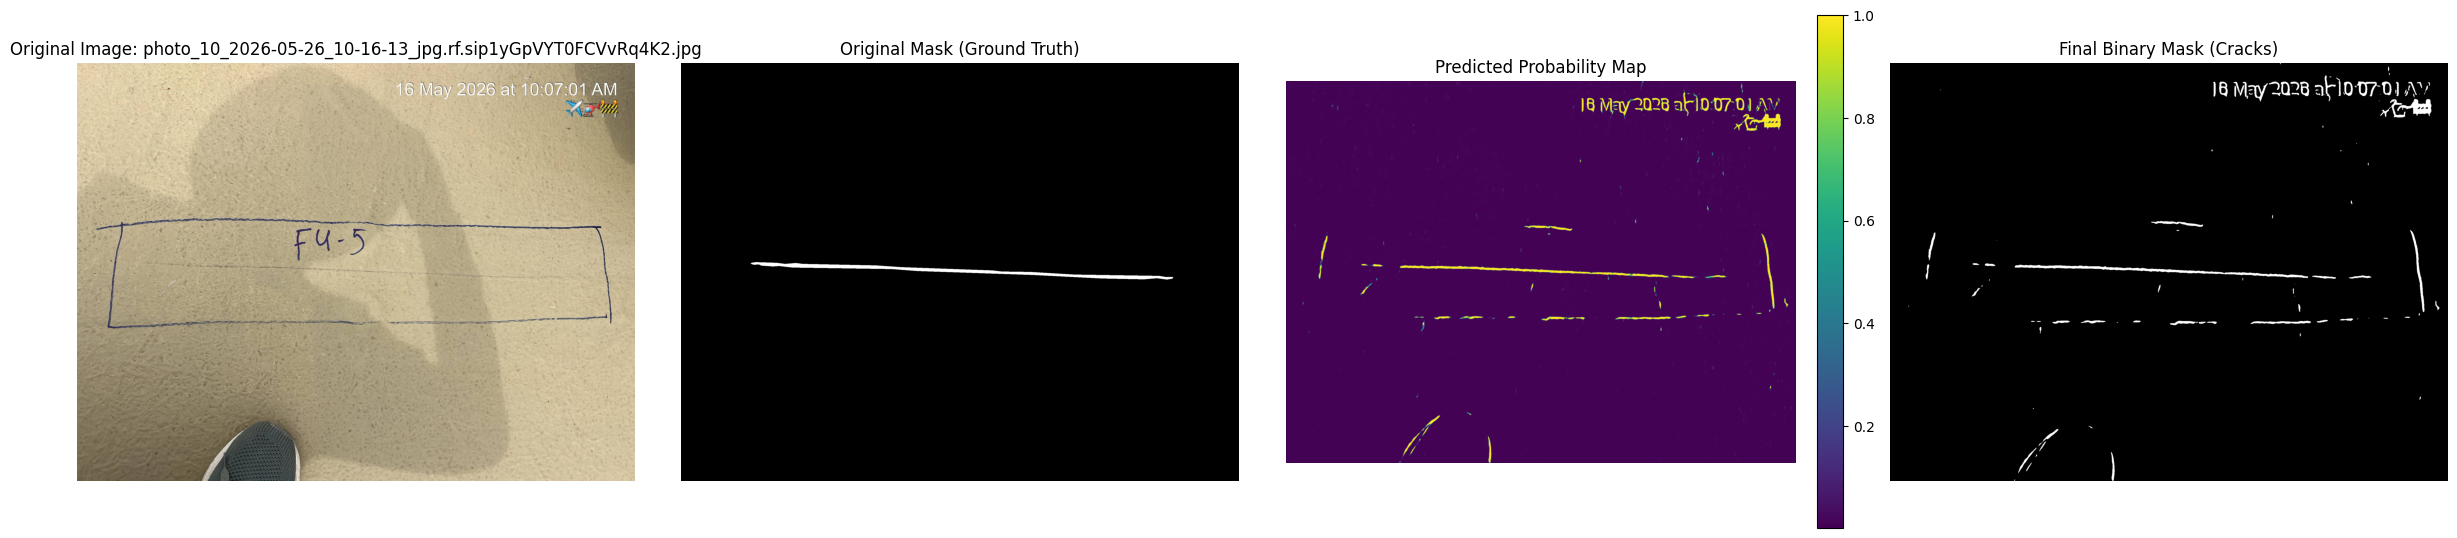

Results for photo_10_2026-05-26_10-16-13_jpg.rf.sip1yGpVYT0FCVvRq4K2.jpg saved to /content/drive/MyDrive/UAV_Segmentation_Results/

Processing image 5/5: photo_13_2026-05-26_10-16-13_jpg.rf.mkOskybz3G0LrFyEs1QG.jpg
Starting inference on /content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test/images/photo_13_2026-05-26_10-16-13_jpg.rf.mkOskybz3G0LrFyEs1QG.jpg
Processing image of size: 1920x2560
Inference complete.


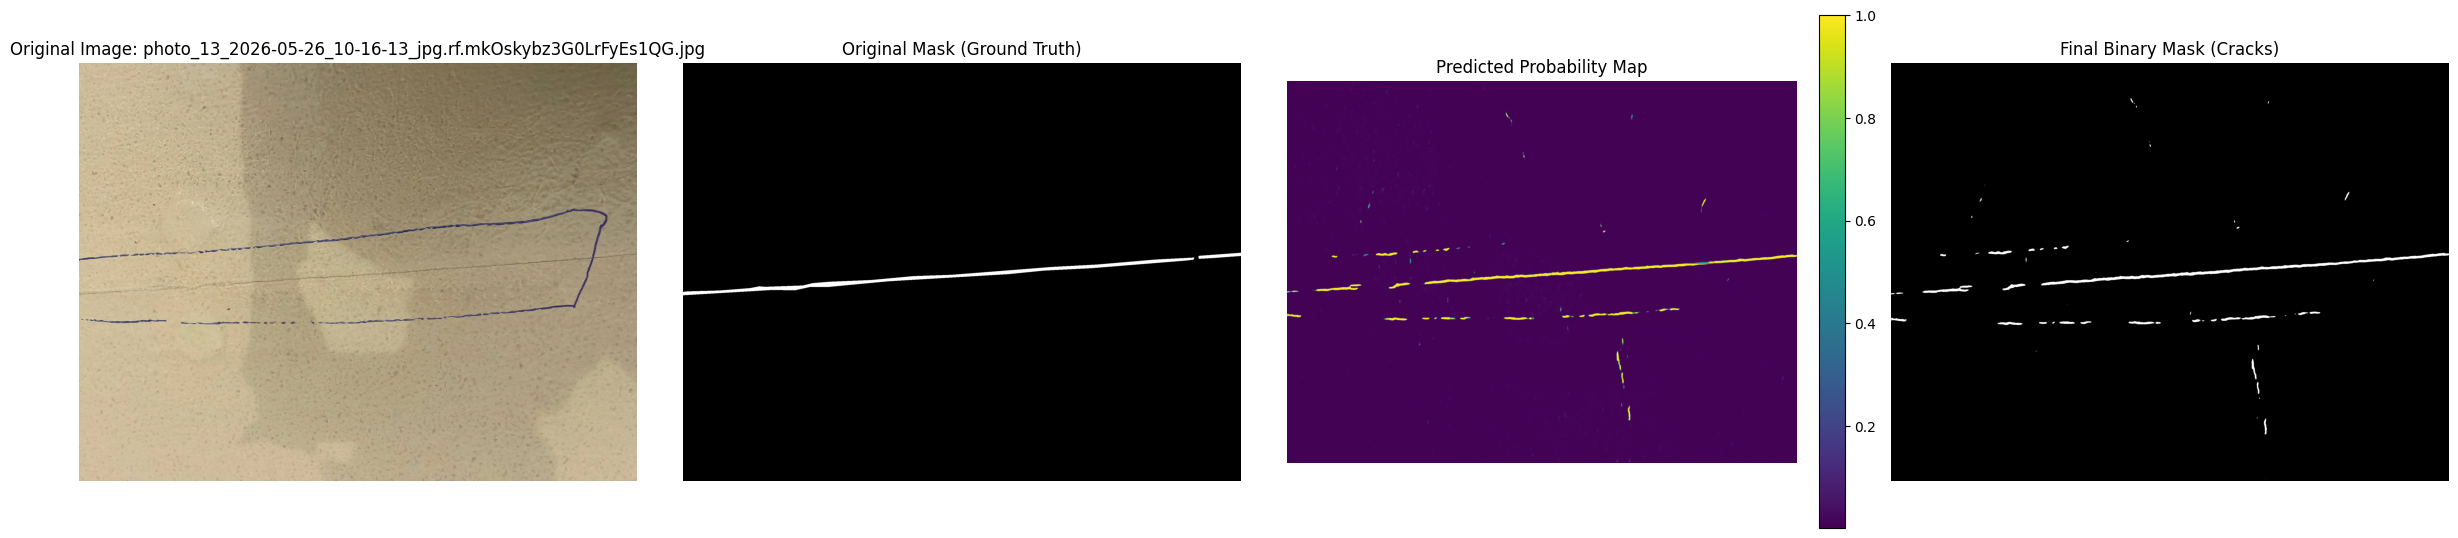

Results for photo_13_2026-05-26_10-16-13_jpg.rf.mkOskybz3G0LrFyEs1QG.jpg saved to /content/drive/MyDrive/UAV_Segmentation_Results/


In [14]:
# Define input paths for images and masks for inference
# These paths should point to the 'images' and 'masks' subfolders within the test data directory
BASE_TEST_DIR = Path('/content/drive/MyDrive/Crack Detection and Segmentation on Large-Scale Aerial High-Resolution Images/datasets/actual_images/v1/datasets_v1_annotated_masked/test')
INPUT_IMAGES_PATH_INFERENCE = BASE_TEST_DIR / 'images'
INPUT_MASKS_PATH_INFERENCE = BASE_TEST_DIR / 'masks'

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

image_files = []
for ext in ('*.png', '*.jpg', '*.jpeg'):
    image_files.extend(list(INPUT_IMAGES_PATH_INFERENCE.glob(ext)))

if not image_files:
    print(f"No image files found in {INPUT_IMAGES_PATH_INFERENCE}")
else:
    print(f"Found {len(image_files)} images in {INPUT_IMAGES_PATH_INFERENCE}. Starting inference...")
    for i, current_image_path in enumerate(image_files):
        print(f"\nProcessing image {i+1}/{len(image_files)}: {current_image_path.name}")

        # Clear CUDA cache before processing each image to free up memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # --- 9.6. Execute Inference ---
        print(f"Starting inference on {current_image_path}")
        original_img, prob_map, binary_mask = run_inference_on_large_image(
            str(current_image_path), model, PATCH_SIZE, OVERLAP_RATIO, get_inference_transform(), tta_enabled=False # TTA disabled to prevent OOM
        )

        print("Inference complete.")

        # Load ground truth mask
        mask_path = INPUT_MASKS_PATH_INFERENCE / current_image_path.name
        original_mask = None
        if mask_path.exists():
            original_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            # Ensure mask is binary (0 or 255)
            original_mask = (original_mask > 127).astype(np.uint8) * 255
        else:
            print(f"Warning: Mask not found for {current_image_path.name} at {mask_path}. Will not display ground truth mask.")

        # --- 9.7. Visualize Results ---
        # Display the original image, the original mask, the predicted probability map, and the final binary crack mask.
        if original_mask is not None:
            fig, axes = plt.subplots(1, 4, figsize=(24, 6))
            axes[0].imshow(original_img)
            axes[0].set_title(f"Original Image: {current_image_path.name}")
            axes[0].axis('off')

            axes[1].imshow(original_mask, cmap='gray')
            axes[1].set_title("Original Mask (Ground Truth)")
            axes[1].axis('off')

            im1 = axes[2].imshow(prob_map, cmap='viridis')
            axes[2].set_title("Predicted Probability Map")
            axes[2].axis('off')
            plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)

            axes[3].imshow(binary_mask, cmap='gray')
            axes[3].set_title("Final Binary Mask (Cracks)")
            axes[3].axis('off')
        else:
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            axes[0].imshow(original_img)
            axes[0].set_title(f"Original Image: {current_image_path.name}")
            axes[0].axis('off')

            im1 = axes[1].imshow(prob_map, cmap='viridis')
            axes[1].set_title("Predicted Probability Map")
            axes[1].axis('off')
            plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

            axes[2].imshow(binary_mask, cmap='gray')
            axes[2].set_title("Final Binary Mask (Cracks)")
            axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        # --- 9.8. Save Results ---
        # Save the generated masks and an overlay image to Google Drive.
        output_base_name = os.path.splitext(os.path.basename(current_image_path))[0]
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"{output_base_name}_prediction_prob.png"), (prob_map * 255).astype(np.uint8)) # Save prob map as 0-255 image
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"{output_base_name}_prediction_binary.png"), binary_mask)
        cv2.imwrite(os.path.join(OUTPUT_DIR, f"{output_base_name}_original_with_mask_overlay.png"),
                    cv2.addWeighted(original_img, 0.7, cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2RGB), 0.3, 0)) # Overlay mask on original

        print(f"Results for {current_image_path.name} saved to {OUTPUT_DIR}")

This notebook implements a U-Net model for crack detection in UAV imagery. The key methods used for training and inference are:

**Model Training:**
*   **U-Net Architecture:** A standard U-Net convolutional neural network is used for semantic segmentation.
*   **Loss Function:** A hybrid loss combining Binary Cross-Entropy with Dice Loss is employed for effective training, especially with class imbalance.
*   **Data Augmentation:** Albumentations is utilized to define image augmentation strategies (e.g., flips, rotations, elastic transforms, brightness/contrast adjustments, CLAHE) to promote robust model training.
*   **Optimization:** The Adam optimizer is used, along with a `ReduceLROnPlateau` learning rate scheduler.
*   **Early Stopping:** Training includes an early stopping mechanism based on validation loss to prevent overfitting.

**Inference:**
*   **Sliding Window:** A sliding window approach is used to process large images in patches.
*   **CLAHE Preprocessing:** Contrast Limited Adaptive Histogram Equalization (CLAHE) is applied to images before inference to enhance local contrast.
*   **Test-Time Augmentation (TTA):** (Although disabled in the provided code snippet due to potential OOM issues, the framework for TTA is included) TTA involves averaging predictions from different transformations (e.g., flips, rotations) to enhance prediction accuracy.
*   **Prediction Averaging:** Overlapping regions from the sliding window are averaged to create a smooth, coherent full image prediction map.
*   **Thresholding:** A confidence threshold is applied to the probability map to generate the final binary crack mask.


**Note:** Rather than segmenting the crack itself, the model is trying to frame the artifacts prior to its shapes, the results look like the shape drawing.